# ARTI 404 - Image Processing
## Lab 3: Image Manipulations using OpenCV Library

Outcome#1: Explain how digital images are represented and manipulated in a
computer. Apply some geometric transformations to the images.

The manual reads `./images/input.jpg`. That file is not part of this
repository, so Step 0 builds an equivalent color image (`astronaut_256.png`)
from skimage's built-in sample data and writes it into `../images`, alongside
the grayscale `cameraman_256.png` already used in Lab 2. Every later step
then loads images by path exactly the way the manual does.

Displaying is done with matplotlib instead of `cv2.imshow`/`cv2.waitKey`, so
the whole lab can be run start to finish without spawning external image
viewer windows.

In [6]:
import os

import cv2
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt

## Step 0: Prepare the working images on disk

In [7]:
# Paths are resolved relative to this file so the lab runs from anywhere.
# __file__ is undefined inside a notebook kernel, which starts in the notebook's
# own directory, so fall back to the working directory there.
try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.getcwd()

IMAGES_DIR = os.path.join(HERE, "..", "images")
os.makedirs(IMAGES_DIR, exist_ok=True)

INPUT_PATH = os.path.join(IMAGES_DIR, "astronaut_256.png")     # stands in for input.jpg
CAMERAMAN_PATH = os.path.join(IMAGES_DIR, "cameraman_256.png")  # already used in Lab 2
OUTPUT_PATH = os.path.join(IMAGES_DIR, "lab3_output.jpg")

if not os.path.exists(INPUT_PATH):
    # skimage's astronaut() is a 512x512 RGB sample photo; resize to match the
    # 256x256 grayscale images already used elsewhere in this repo.
    resized = ski.transform.resize(ski.data.astronaut(), (256, 256), anti_aliasing=True)
    ski.io.imsave(INPUT_PATH, ski.util.img_as_ubyte(resized))

print("Input image:", INPUT_PATH)
print("Cameraman image:", CAMERAMAN_PATH)

Input image: c:\Users\jaber\OneDrive\Desktop\Image Processing\labs\lab3\..\images\astronaut_256.png
Cameraman image: c:\Users\jaber\OneDrive\Desktop\Image Processing\labs\lab3\..\images\cameraman_256.png


## Step#1: Read an image using the OpenCV library

`cv2.imread` loads the file into a NumPy array (BGR channel order). The
manual's `cv2.imshow` + `cv2.waitKey` pops up an OS window; here the array is
shown inline with matplotlib instead, which expects RGB, so the channels are
reversed for display only.

dtype: uint8 shape: (256, 256, 3) type: <class 'numpy.ndarray'>


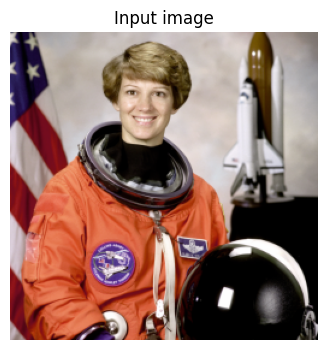

In [8]:
img = cv2.imread(INPUT_PATH)
print("dtype:", img.dtype, "shape:", img.shape, "type:", type(img))

plt.figure(figsize=(4, 4))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Input image")
plt.axis("off")
plt.show()

## Step#2: Load an image in grayscale mode

The conversion to grayscale can be performed while reading the image, by
passing `cv2.IMREAD_GRAYSCALE`.

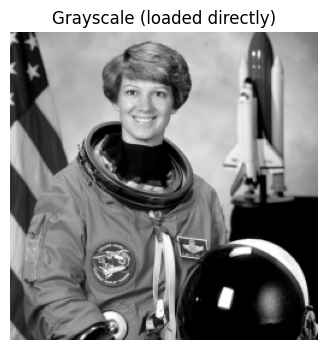

In [9]:
gray_img = cv2.imread(INPUT_PATH, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(4, 4))
plt.imshow(gray_img, cmap="gray", vmin=0, vmax=255)
plt.title("Grayscale (loaded directly)")
plt.axis("off")
plt.show()

## Step#3: Save an image

`cv2.imwrite` writes an array back out to a file.

In [10]:
cv2.imwrite(OUTPUT_PATH, gray_img)
print("Saved:", OUTPUT_PATH, "exists:", os.path.exists(OUTPUT_PATH))

Saved: c:\Users\jaber\OneDrive\Desktop\Image Processing\labs\lab3\..\images\lab3_output.jpg exists: True


## Step#4: Convert an image to different color spaces

Rather than loading grayscale directly, `cv2.cvtColor` converts an
already-loaded color image. OpenCV exposes around 190 color-conversion
flags (`COLOR_*`); the code below lists how many are available and then
converts to YUV, a color model used for television broadcast where Y is
luma (physical linear-space brightness) and U/V are the blue and red
chrominance projections.

374 COLOR_* flags available in this OpenCV build


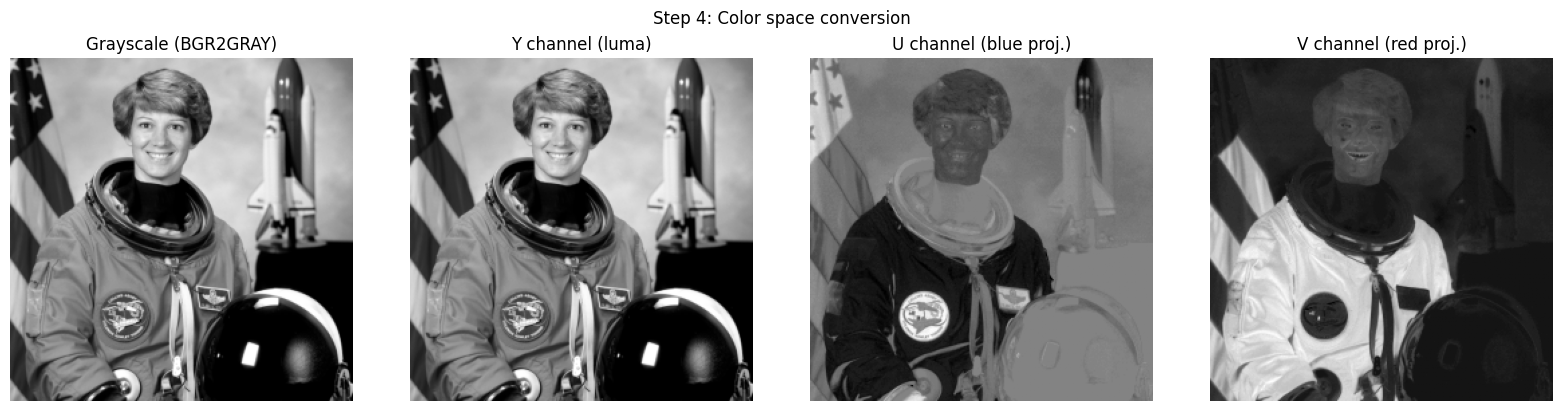

In [11]:
img = cv2.imread(INPUT_PATH)
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

color_flags = [x for x in dir(cv2) if x.startswith("COLOR_")]
print(f"{len(color_flags)} COLOR_* flags available in this OpenCV build")

yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

fig, axs = plt.subplots(1, 4, figsize=(16, 4), layout="constrained")
fig.suptitle("Step 4: Color space conversion")
for ax, im, title in zip(
    axs,
    [gray_img, yuv_img[:, :, 0], yuv_img[:, :, 1], yuv_img[:, :, 2]],
    ["Grayscale (BGR2GRAY)", "Y channel (luma)", "U channel (blue proj.)", "V channel (red proj.)"],
):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.show()

## Task#1: Geometric transformations

Use any image processing library and apply the following geometric
transformations over the image:

1. Increase the size of the image.
2. Rotate the image by 120 degrees.
3. Perform shear operations over the image.

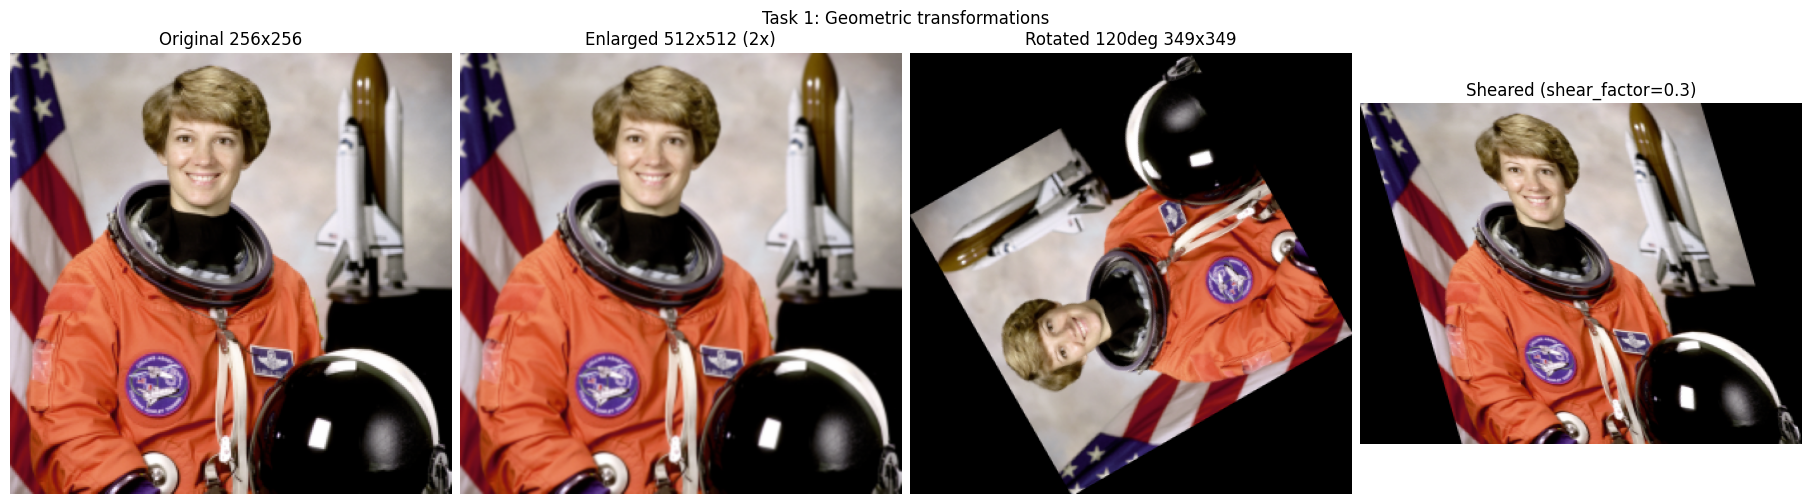

In [12]:
base = cv2.cvtColor(cv2.imread(INPUT_PATH), cv2.COLOR_BGR2RGB)
h, w = base.shape[:2]

# 1. Enlarge the image (2x in both dimensions).
scale = 2.0
enlarged = cv2.resize(base, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)

# 2. Rotate by 120 degrees about the image center, keeping the full rotated
#    image in frame (the output canvas grows to fit the rotated corners).
angle = 120
center = (w / 2, h / 2)
rot_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
cos, sin = abs(rot_matrix[0, 0]), abs(rot_matrix[0, 1])
new_w = int(h * sin + w * cos)
new_h = int(h * cos + w * sin)
rot_matrix[0, 2] += new_w / 2 - center[0]
rot_matrix[1, 2] += new_h / 2 - center[1]
rotated = cv2.warpAffine(base, rot_matrix, (new_w, new_h))

# 3. Shear: a horizontal shear factor tilts each row sideways proportional to
#    its distance from the top, via the affine matrix [[1, shear, 0], [0, 1, 0]].
shear_factor = 0.3
shear_matrix = np.float32([[1, shear_factor, 0], [0, 1, 0]])
sheared_w = w + int(shear_factor * h)
sheared = cv2.warpAffine(base, shear_matrix, (sheared_w, h))

fig, axs = plt.subplots(1, 4, figsize=(18, 5), layout="constrained")
fig.suptitle("Task 1: Geometric transformations")
for ax, im, title in zip(
    axs,
    [base, enlarged, rotated, sheared],
    [f"Original {w}x{h}", f"Enlarged {enlarged.shape[1]}x{enlarged.shape[0]} (2x)",
     f"Rotated 120deg {rotated.shape[1]}x{rotated.shape[0]}", f"Sheared ({shear_factor=})"],
):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis("off")
plt.show()

## Task#2: Intensity transformations

Use any image processing library and apply the following intensity
transformations over the image:

1. Create a negative image.
2. Log transform (choose an appropriate constant for the image).
3. Power law / gamma transform (choose a gamma that increases contrast).

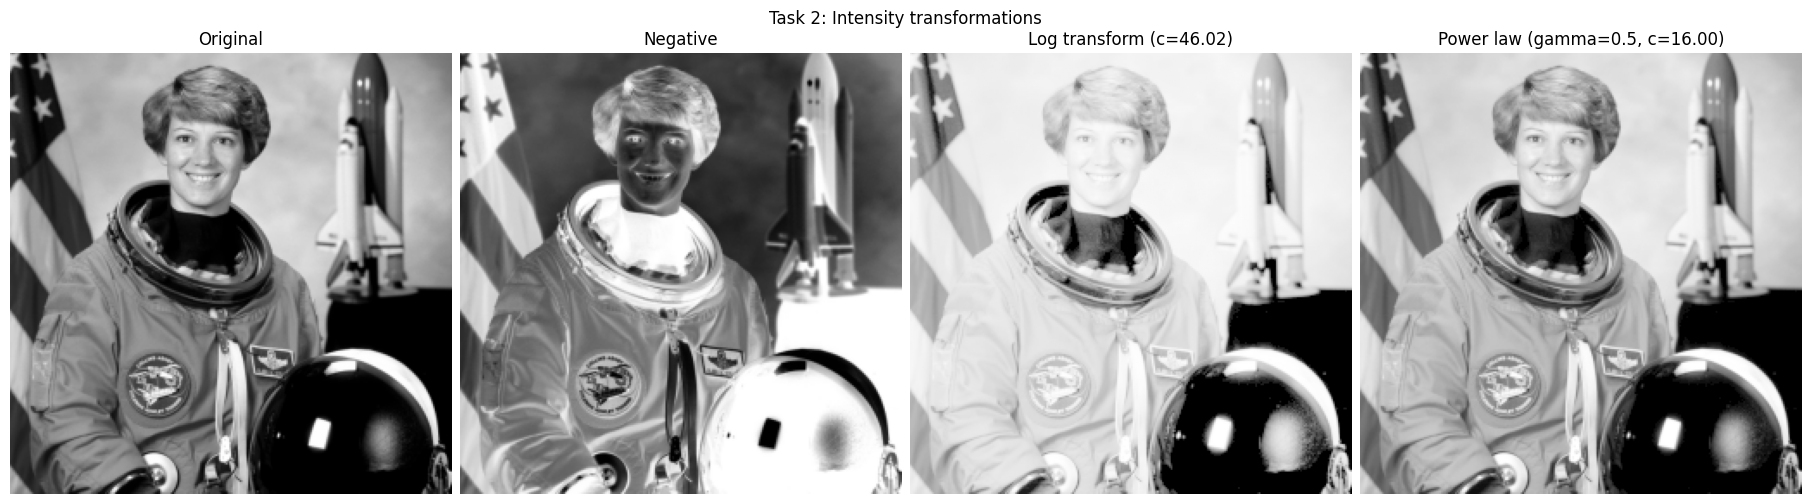

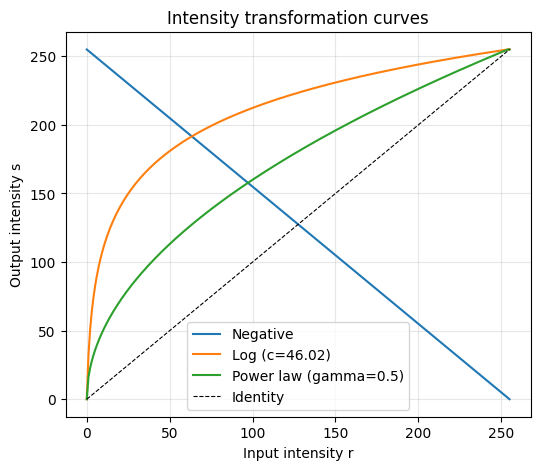

In [13]:
gray = cv2.imread(INPUT_PATH, cv2.IMREAD_GRAYSCALE).astype(np.float64)

# 1. Negative: s = (L-1) - r, with L-1 = 255 for 8-bit images.
negative = (255 - gray).astype(np.uint8)

# 2. Log transform: s = c * log(1 + r). c is chosen so the brightest input
#    pixel (255) maps back to 255, which keeps the output in range.
c_log = 255 / np.log(1 + gray.max())
log_transformed = (c_log * np.log(1 + gray)).astype(np.uint8)

# 3. Power law (gamma): s = c * r^gamma. gamma < 1 brightens shadows and
#    increases contrast in dark regions; c again normalizes so 255 -> 255.
gamma = 0.5
c_gamma = 255 / (gray.max() ** gamma)
gamma_transformed = (c_gamma * (gray ** gamma)).astype(np.uint8)

gray_u8 = gray.astype(np.uint8)
fig, axs = plt.subplots(1, 4, figsize=(18, 5), layout="constrained")
fig.suptitle("Task 2: Intensity transformations")
for ax, im, title in zip(
    axs,
    [gray_u8, negative, log_transformed, gamma_transformed],
    ["Original", "Negative", f"Log transform (c={c_log:.2f})", f"Power law ({gamma=}, c={c_gamma:.2f})"],
):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.show()

# The input-output mapping curves make the effect of each transform explicit.
r = np.arange(256)
plt.figure(figsize=(6, 5))
plt.plot(r, 255 - r, label="Negative")
plt.plot(r, c_log * np.log(1 + r), label=f"Log (c={c_log:.2f})")
plt.plot(r, np.clip(c_gamma * (r ** gamma), 0, 255), label=f"Power law ({gamma=})")
plt.plot(r, r, "k--", linewidth=0.8, label="Identity")
plt.xlabel("Input intensity r")
plt.ylabel("Output intensity s")
plt.title("Intensity transformation curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()